# Guillotine — Generation time and reasoning tokens (from raw OpenRouter logs)

Different source from the other notebooks: not the results Excel file, but the
raw JSONL backups (`raw_logs/*.jsonl`) — needed because they contain
`usage.completion_tokens_details.reasoning_tokens`, the native count
of reasoning tokens billed by each provider, never written to
Excel. Question: is generation duration explained by the number of tokens
produced, or is something else going on? And is the reasoning text we see
really everything that was computed?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

RAW_LOGS_DIR = Path("D:/guillotine/guillotine/source/raw_logs")
JSONL_FILES = sorted(RAW_LOGS_DIR.glob("openrouter_*.jsonl"))
# Only the logs from temperature-controlled calls (openrouter_*) - the
# commercial ones (commercial_*.jsonl) are deliberately left out, they have a single
# run with no parameters, not the same experimental design.
print(f"{len(JSONL_FILES)} files found:")
for p in JSONL_FILES:
    print(f"  {p.name}")

records = []
seen_calls = set()
n_duplicate = 0
for path in JSONL_FILES:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            call_key = (r["model"], r["prompt_id"], r["temperature"], r["timestamp"])
            if call_key in seen_calls:
                n_duplicate += 1
                continue
            seen_calls.add(call_key)
            choices = r["response"].get("choices", [])
            if not choices:
                continue
            msg = choices[0].get("message", {}) or {}
            usage = r["response"].get("usage", {}) or {}
            details = usage.get("completion_tokens_details") or {}
            records.append({
                "model": r["model"], "prompt_id": r["prompt_id"], "temperature": r["temperature"],
                "duration_s": r["duration_s"], "completion_tokens": usage.get("completion_tokens"),
                "reasoning_tokens": details.get("reasoning_tokens"),
                "finish_reason": choices[0].get("finish_reason"),
                "reasoning_text_len": len(msg.get("reasoning") or ""),
                "content_text_len": len(msg.get("content") or ""),
            })

if n_duplicate:
    print(f"\n{n_duplicate} duplicate calls across files (same model/item/temperature/timestamp) - discarded.")

df = pd.DataFrame(records)
n_models = df['model'].nunique()
print(f"\n{len(df)} unique calls, {n_models} models")
df.groupby("model").agg(n=("duration_s", "size"), reasoning_mean=("reasoning_tokens", "mean")).round(1)

16 files found:
  openrouter_20260820_115031.jsonl
  openrouter_20260820_120923.jsonl
  openrouter_20260820_130334.jsonl
  openrouter_20260820_131102.jsonl
  openrouter_20260820_131340.jsonl
  openrouter_20260821_111333.jsonl
  openrouter_20260821_141608.jsonl
  openrouter_20260821_154319.jsonl
  openrouter_20260822_100518.jsonl
  openrouter_20260823_083125.jsonl
  openrouter_20260824_052235.jsonl
  openrouter_20260825_051402.jsonl
  openrouter_20260826_060719.jsonl
  openrouter_20260827_074326.jsonl
  openrouter_20260827_084448.jsonl
  openrouter_20260829_100509.jsonl

5422 unique calls, 64 models


,n,reasoning_mean
model,,
aion-labs/aion-3.0-mini,90,6454.8
amazon/nova-2-lite-v1,90,0.0
amazon/nova-micro-v1,90,0.0
arcee-ai/trinity-large-thinking,89,17972.9
bytedance-seed/seed-1.6-flash,88,3085.8
...,...,...
z-ai/glm-4.5-air,90,2684.3
z-ai/glm-4.6v,90,917.3
z-ai/glm-4.7,88,13328.0


## Who really reasons, and who doesn't

The `reasoning_tokens` field is reliable for this: zero for
non-reasoning models, non-null/present for reasoning models - a direct
check, not an inference from the model's name.

In [3]:
reasoning_means = df.groupby("model")["reasoning_tokens"].mean().sort_values(ascending=False)
print("Mean reasoning_tokens per model (0 = no reasoning observed):")
reasoning_means.round(1)

Mean reasoning_tokens per model (0 = no reasoning observed):


model
qwen/qwen3.7-flash                 24352.8
qwen/qwen3.5-122b-a10b             18431.4
z-ai/glm-4.7-flash                 18216.6
arcee-ai/trinity-large-thinking    17972.9
z-ai/glm-5.2:free                  16727.2
                                    ...   
openai/gpt-3.5-turbo                   0.0
openai/gpt-4o-mini                     0.0
sao10k/l3-lunaris-8b                   0.0
upstage/solar-pro-3                    0.0
upstage/solar-pro4                     0.0
Name: reasoning_tokens, Length: 64, dtype: float64

## Is the visible reasoning text complete, or is it a summary?

Character-to-token ratio in the `reasoning` text: normal English has
about 4 characters per token. A much lower ratio indicates that the
displayed text is shorter than the billed count implies -
a summary, not the full reasoning.

In [4]:
reasoning_models = reasoning_means[reasoning_means > 0].index.tolist()

density_rows = []
for m in reasoning_models:
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 0) & (df["reasoning_text_len"] > 0)]
    if len(sub) < 3:
        continue
    density_rows.append({
        "model": m, "n": len(sub),
        "chars_per_token": (sub["reasoning_text_len"] / sub["reasoning_tokens"]).median(),
    })

density_df = pd.DataFrame(density_rows).sort_values("chars_per_token")
print("~4 chars/token = full text shown. Much below 4 = text is summarized relative to the actual computation.")
density_df.round(2)

~4 chars/token = full text shown. Much below 4 = text is summarized relative to the actual computation.


,model,n,chars_per_token
12,bytedance-seed/seed-2-1-turbo,90,0.89
0,qwen/qwen3.7-flash,90,3.49
4,z-ai/glm-5.2:free,4,3.65
1,qwen/qwen3.5-122b-a10b,88,3.65
7,qwen/qwen3.7-plus,89,3.68
23,bytedance-seed/seed-1.6-flash,88,3.76
19,xiaomi/mimo-v2.5,25,3.85
6,z-ai/glm-4.7,88,3.85
21,nvidia/nemotron-3-ultra-550b-a55b,87,3.87
13,inclusionai/ling-3.0-flash,90,3.87


## Duration explained by the number of tokens: how much, and at what speed

Direct correlation (not just a hypothesis) between `reasoning_tokens` and
`duration_s`, per model - and the seconds/token rate, which is a
comparable measure of pure inference speed across different providers.

In [5]:
rate_rows = []
for m in reasoning_models:
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 50)]
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub["reasoning_tokens"], sub["duration_s"])
    rate_rows.append({
        "model": m, "n": len(sub),
        "rho_token_duration": rho, "p_value": p,
        "s_per_token_median": (sub["duration_s"] / sub["reasoning_tokens"]).median(),
        "tokens_per_second": 1 / (sub["duration_s"] / sub["reasoning_tokens"]).median(),
    })

rate_df = pd.DataFrame(rate_rows).sort_values("s_per_token_median")
rate_df.round(4)

,model,n,rho_token_duration,p_value,s_per_token_median,tokens_per_second
29,liquid/lfm-2.5-2.6b:free,9,0.4667,0.2054,0.0047,211.2717
12,inclusionai/ling-3.0-flash,90,0.8886,0.0000,0.0053,186.9558
0,qwen/qwen3.7-flash,90,0.9921,0.0000,0.0058,173.3847
3,arcee-ai/trinity-large-thinking,89,0.9792,0.0000,0.0058,171.6580
21,stepfun/step-3.7-flash,37,0.9791,0.0000,0.0066,152.5830
10,qwen/qwen3-next-80b-a3b-thinking,90,0.9497,0.0000,0.0071,140.2549
22,bytedance-seed/seed-1.6-flash,88,0.9505,0.0000,0.0071,140.1443
13,nex-agi/nex-n2-mini,90,0.9602,0.0000,0.0089,112.1782
1,qwen/qwen3.5-122b-a10b,88,0.9216,0.0000,0.0100,100.1616
8,thinkingmachines/inkling-small,90,0.7612,0.0000,0.0104,96.1566


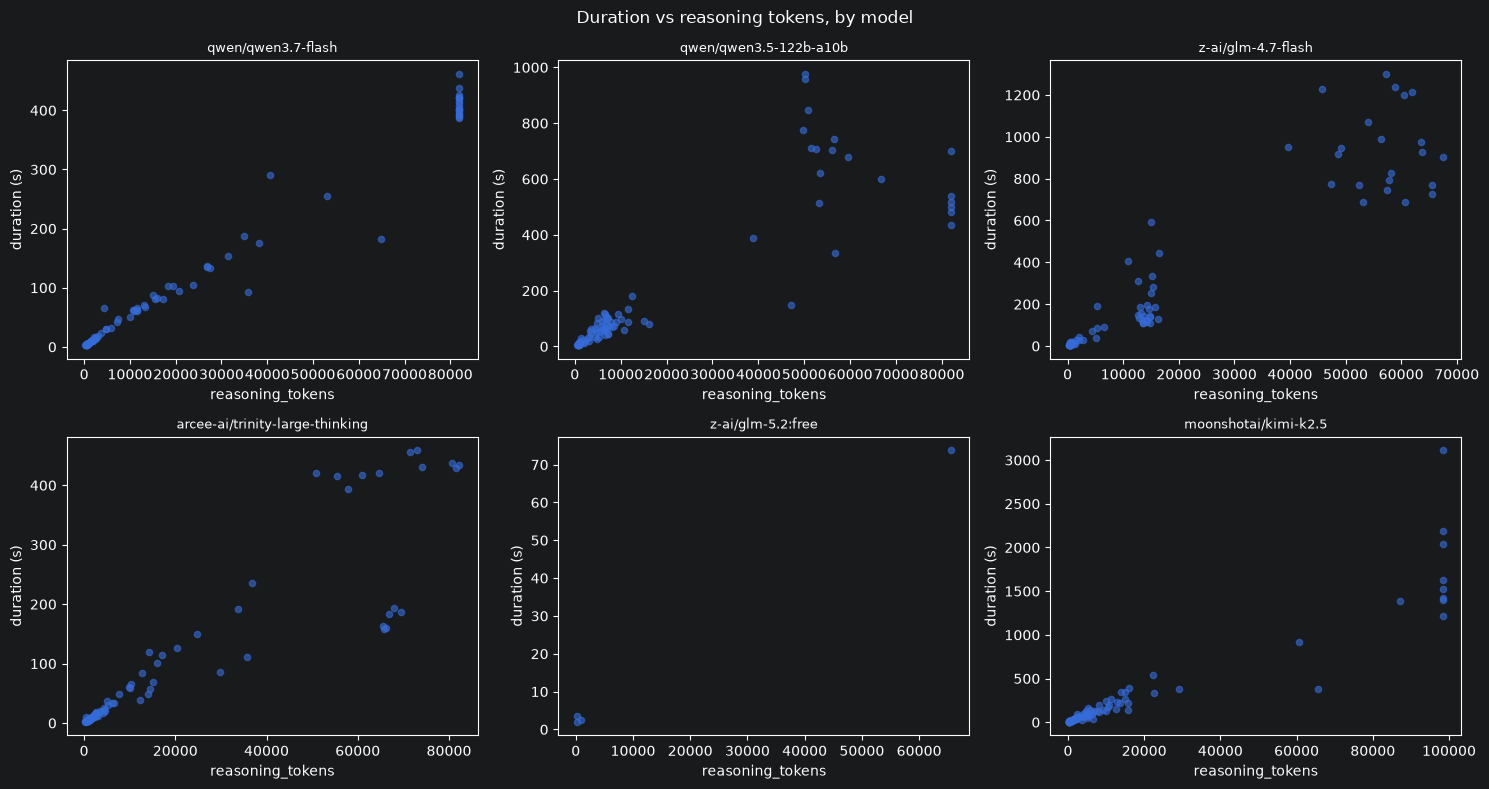

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
for ax, m in zip(axes.flat, reasoning_models[:6]):
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 0)]
    ax.scatter(sub["reasoning_tokens"], sub["duration_s"], alpha=0.6, s=20)
    ax.set_title(m, fontsize=9)
    ax.set_xlabel("reasoning_tokens")
    ax.set_ylabel("duration (s)")
plt.suptitle("Duration vs reasoning tokens, by model")
plt.tight_layout()
plt.show()

## Cases at the cap (65,536 tokens, no response)

Same phenomenon already documented for `z-ai/glm-5.2` — a model that exhausts
the maximum generation budget without ever emitting a final response.
Here verified on other models, with `finish_reason` as direct confirmation
instead of being inferred solely from duration clustering.

In [7]:
at_cap = df[df["reasoning_tokens"] >= 65536]
print(f"{len(at_cap)} calls at the maximum token cap, no response produced:")
at_cap[["model", "prompt_id", "finish_reason", "content_text_len"]]

80 calls at the maximum token cap, no response produced:


,model,prompt_id,finish_reason,content_text_len
103,z-ai/glm-5.2:free,guillo_01,length,0
603,nex-agi/nex-n2-mini,guillo_29,length,0
759,qwen/qwen3.7-flash,guillo_05,stop,5
763,qwen/qwen3.7-flash,guillo_09,stop,3
765,qwen/qwen3.7-flash,guillo_11,stop,6
...,...,...,...,...
5032,qwen/qwen3.5-122b-a10b,guillo_29,stop,150124
5036,qwen/qwen3.5-122b-a10b,guillo_03,stop,6
5041,qwen/qwen3.5-122b-a10b,guillo_09,stop,6
5060,qwen/qwen3.5-122b-a10b,guillo_29,stop,6


In [8]:
print("Items that recur multiple times among the exhausted cases (likely structural difficulty, not random):")
at_cap["prompt_id"].value_counts()

Items that recur multiple times among the exhausted cases (likely structural difficulty, not random):


prompt_id
guillo_09    13
guillo_29    11
guillo_03     7
guillo_23     7
guillo_24     6
guillo_22     5
guillo_11     3
guillo_25     3
guillo_20     3
guillo_05     2
guillo_30     2
guillo_12     2
guillo_02     2
guillo_19     2
guillo_04     2
guillo_08     2
guillo_13     2
guillo_01     1
guillo_26     1
guillo_07     1
guillo_14     1
guillo_28     1
guillo_27     1
Name: count, dtype: int64

### Takeaway

`guillo_09` (petrichor) appears among the exhausted cases - the same item that
Claude Opus 5 had solved successfully (4,272 tokens, correct
result). Two different models here get stuck on the same item
up to the maximum cap, without ever reaching an answer. It's worth
keeping this as a direct counterexample in the qualitative write-up: same
item, same underlying factor (a rare, underrepresented word), opposite
outcomes depending on the model - it's not the rarity of the word alone that
decides the result, it's how the specific model handles it.